# Breather Soliton Ikeda Map

This notebook replicates figures 1ab in the MJ/Jae [breather soliton paper](https://www.nature.com/articles/ncomms14569)

It does this by pumping at a given detuning and seeding the breather.

**Notes:**
1. This is obvious, but the pump in the cavity has to be in phase with the seeded soliton. So if the seed is fully real, the pump should have $e^{-i \pi / 2}$
2. The seed they give is in normalized units (its $F(\tau)$ not $E(\tau)$)
3. It seems like you can apply the intracavity loss either continuously ($\alpha_i / L$ in the `differential_operator`) or at the end of each cycle when you enforce the beamsplitter

In [1]:
from NLSE import split_step
import numpy as np

alpha = 0.01521 # loss per rt
coupling_coeff = 0.01856 # Input coupling coeff (theta)
gamma = 0.9 # W^-1 m^-1
cavity_length = 8.8757e-3 # m
alpha_int = 2 * alpha - coupling_coeff
alpha_int_per_m = alpha_int / cavity_length
# t_rt = 5e-12 # s
t_rt = 1 / 16.0367e9

# beta_2 = -36.5836 / ( 1e12 ** 2 ) / 1e3 # s^2 m^-1
# beta_3 = -0.45448 / ( 1e12 ** 3 ) / 1e3 # s^3 m^-1
# beta_4 = 0.0042233 / ( 1e12 ** 4 ) / 1e3 # s^4 m^-1
# beta_5 = -1.6613e-5 / ( 1e12 ** 5 ) / 1e3 # s^5 m^-1

beta_2 = -40 / ( 1e12 ** 2 ) / 1e3 # s^2 m^-1
beta_3 = 0 / ( 1e12 ** 3 ) / 1e3 # s^3 m^-1
beta_4 = 0 / ( 1e12 ** 4 ) / 1e3 # s^4 m^-1
beta_5 = 0 / ( 1e12 ** 5 ) / 1e3 # s^5 m^-1

intensity_in = 15 / ( gamma * cavity_length * coupling_coeff / alpha ** 3 )
# intensity_in = 0.18

ring_bus_bs = np.array([[np.sqrt(1 - coupling_coeff), 1j * np.sqrt(coupling_coeff)], 
                        [1j * np.sqrt(coupling_coeff), np.sqrt(1 - coupling_coeff)]])
_norm_detuning = 10

tau = np.linspace(-t_rt / 2, t_rt / 2, 8192, endpoint=False)
tau_normalized = tau * np.sqrt( 2 * alpha / ( abs(beta_2) * cavity_length ) )
freq = np.fft.fftfreq(len(tau), tau[1] - tau[0])
wavelength = 2.998e8 / ( freq + 2.998e8 / 1550e-9 )

detuning = _norm_detuning * alpha

ring_bus_detuning = np.array([[1, 0], [0, np.exp(-1j * detuning)]])
ring_bus = ring_bus_bs @ ring_bus_detuning

omega_0 = 2 * np.pi * 2.998e8 / 1560e-9

# T_raman = 0.7e-15
T_raman = 0
T_self_steepening = 1 / omega_0
# T_self_steepening = 0 / omega_0

intensity_in

0.3560047604186051

In [2]:
def make_seed(detuning, intensity_in):
    '''
    This includes the pump field 

    Equation is direct from Yun's thesis equation 1.89. 

    Definition of the normalized units is from Breather paper, but it's the 
    same as Yun's thesis just without confusing fourier transform terms

    Arguments:
        detuning: real pump detuning
        intensity_in: pump intensity in W

    Returns:
        A_seed: Units are W^1/2 (not normalized field)
    '''
    S = np.sqrt(gamma * coupling_coeff * cavity_length / alpha ** 3) * np.sqrt(intensity_in)
    delta = detuning / alpha
    
    thresh = np.arccosh(1e100 / (np.sqrt(alpha / (gamma * cavity_length)) * np.sqrt(2 * delta)))
    mask = np.abs(np.sqrt(delta) * tau_normalized) < thresh
    
    F = np.zeros(tau_normalized.shape, dtype=complex)
    
    F[mask] = np.sqrt(2 * delta) * 1 / np.cosh(np.sqrt(delta) * tau_normalized[mask]) \
        * np.exp(1j * np.arccos(np.sqrt(8 * delta) / (np.pi * S))) \
        - 1j * S / delta
    return F / np.sqrt(gamma * cavity_length / alpha)

In [3]:
import matplotlib.pyplot as plt

Ain = -1j * np.sqrt(intensity_in) * np.ones(tau.shape)
# seed = np.sqrt(alpha / (gamma * cavity_length)) * np.sqrt(2 * 4.5) / np.cosh(np.sqrt(4.5) * tau_normalized) * np.exp(1j * np.arccos(np.sqrt(8 * 4.5)/(np.pi * np.sqrt(8.7))))
# seed = np.sqrt(alpha / (gamma * cavity_length)) * np.sqrt(2 * _norm_detuning) / np.cosh(np.sqrt(_norm_detuning) * tau_normalized)
seed = make_seed(detuning, intensity_in)

def nl_operator(A, omega):
    # print(np.max(omega * T_self_steepening))
    self_steepening = np.fft.ifft( 1j * omega * T_self_steepening * np.fft.fft(np.abs(A) ** 2 * A) )
    raman_response = np.fft.ifft( 1j * omega * np.fft.fft(np.abs(A) ** 2) ) * A
    return 1j * gamma * ( np.abs(A) ** 2 + 1j * self_steepening - T_raman * raman_response )

# def nl_operator(A, omega):
#     return 1j * gamma * np.abs(A) ** 2

# def diff_operator(omega):
#     return 1j * beta_2 / 2 * omega ** 2

def diff_operator(omega):
#     return 1j * beta_2 / 2 * omega ** 2 - alpha_int_per_m / 2
    # return 1j * beta_2 / 2 * omega ** 2 + 1j * beta_3 / 6 * omega ** 3 + 1j * beta_4 / 24 * omega ** 4 - alpha_int_per_m / 2
    return 1j * beta_2 / 2 * omega ** 2 + 1j * beta_3 / 6 * omega ** 3 + 1j * beta_4 / 24 * omega ** 4 + 1j * beta_5 / 120 * omega ** 5

z = np.linspace(0, cavity_length, 2, endpoint=True)

# n_rt = round( 10 / alpha )
n_rt = 1000
# T = np.arange(0, n_rt)

A_intra = [ seed ]
# A_trans = []
for ind in range(n_rt):
    A = split_step(A_intra[ind], tau, z, diff_operator, nl_operator, n_integral_iterations=10)
    Anext = 1j * np.sqrt(coupling_coeff) * Ain + np.exp(-1j * detuning - alpha) * A[-1]
    # Anext = 1j * np.sqrt(coupling_coeff) * Ain + np.exp(-1j * detuning) * A[-1]
    # Aout, Anext = ring_bus @ [Ain, A[-1]]
    A_intra.append(Anext)
    # A_trans.append(Aout)
    # break

I slice out the first period so that the seed can converge some

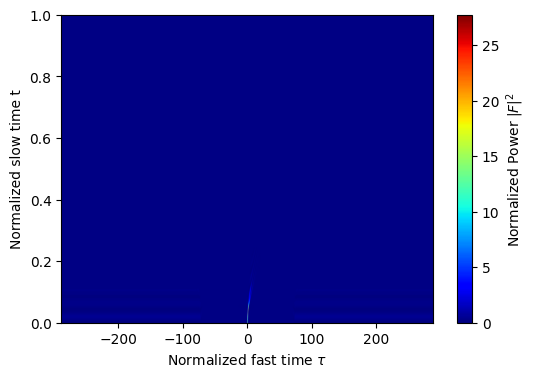

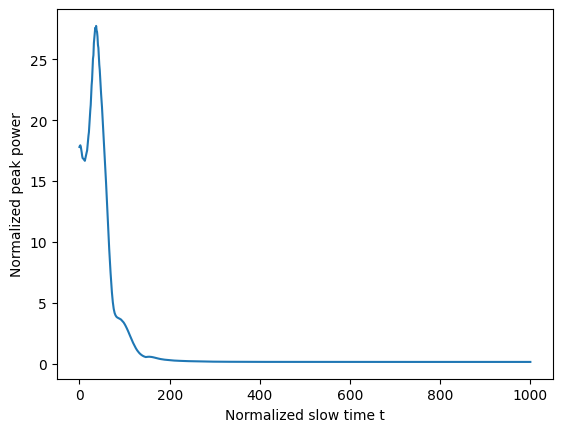

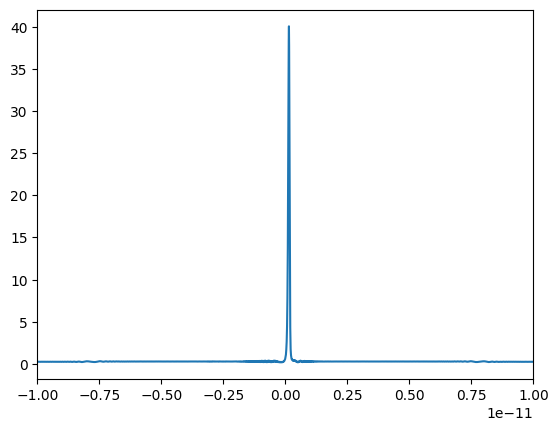

(1500.0, 1900.0)

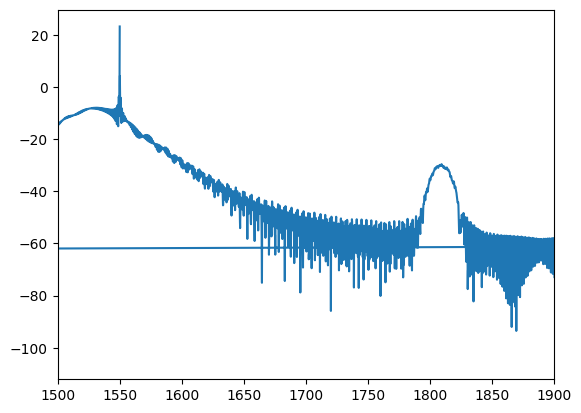

In [4]:
# start = round( 1.34 / alpha )
F_intra = np.array(A_intra) * np.sqrt(gamma * cavity_length / alpha)
# F_intra = np.array(A_intra) * np.sqrt(gamma * cavity_length / alpha)

plt.figure(figsize=(6,4))
plt.imshow(np.abs(F_intra[::-1])**2, extent=[np.min(tau_normalized), np.max(tau_normalized), 0, 1], aspect='auto', cmap='jet')
# plt.xlim(-10, 10)
plt.xlabel('Normalized fast time $\\tau$')
plt.ylabel('Normalized slow time t')
plt.colorbar(label='Normalized Power $|F|^2$')
plt.show()

F_max = np.amax(np.abs(F_intra) ** 2, axis=1)
slow_time = 8 * np.arange(len(F_max)) / len(F_max)
# plt.plot(slow_time, F_max)
plt.plot(F_max)
# plt.ylim(0, 25)
plt.xlabel('Normalized slow time t')
plt.ylabel('Normalized peak power')
plt.show()

plt.plot(tau, np.abs(A_intra[50]) ** 2)
plt.xlim(-1e-11, 1e-11)
plt.show()

dBm = lambda mW: 10 * np.log10(mW)
make_spectrum = lambda A: dBm( 1e3 * np.abs(np.fft.fft(A)) ** 2 / A.size ** 2 )

plt.plot(1e9 * wavelength, make_spectrum(A_intra[50]))
# plt.ylim(bottom=-60)
plt.xlim(1500, 1900)
# plt.yscale('log')

In [7]:
A_intra[51]

array([0.30708489-0.40223132j, 0.30707978-0.4021992j ,
       0.30708489-0.40223131j, ..., 0.30707977-0.40219918j,
       0.3070849 -0.40223132j, 0.30707977-0.40219919j], shape=(8192,))

In [16]:
c = 299792458
hbar = 1.054571817e-34 # J s
omega_0 = 2 * np.pi * c / 1550e-9

# vacuum_noise = np.sqrt(hbar * omega_0 * alpha / 2 * 1 / t_rt)
vacuum_noise = np.sqrt(hbar * omega_0 / t_rt)

In [5]:
normalized_detuning = np.arange(-2.9, 12, 0.001)
detuning = alpha * normalized_detuning

n_rt = round( 1 / alpha )
# n_rt = 5

A_intra = [ np.zeros(tau.shape) ]
for det in detuning:
    _intra = A_intra[-1]
    for _ in range(n_rt):
        noise = vacuum_noise * np.exp(2j * np.pi * np.random.rand(*seed.shape))
        A = split_step(_intra, tau, z, diff_operator, nl_operator, n_integral_iterations=10)
        _intra = 1j * np.sqrt(coupling_coeff) * Ain + noise + np.exp(-1j * det - alpha) * A[-1]
        # Aout, Anext = ring_bus @ [Ain, A[-1]]
        # _intra.append(Anext)
    A_intra.append(_intra)

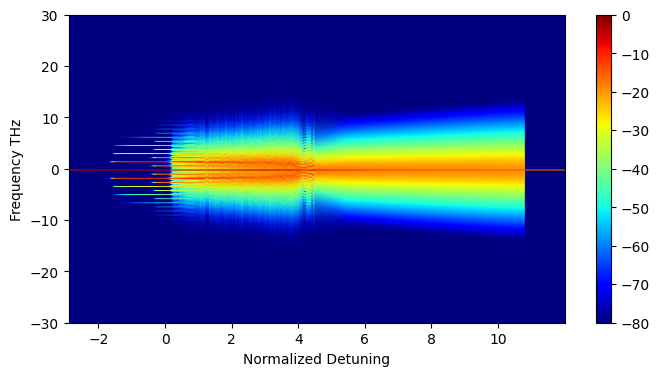

In [26]:
import matplotlib.colors as mcolors

freq = np.fft.fftshift(np.fft.fftfreq(len(tau), tau[1] - tau[0])) / 1e12
data = np.abs( np.fft.fftshift(np.fft.fft(A_intra), axes=1) ) ** 2 

plt.figure(figsize=(8,4))
plt.imshow(10 * np.log10(data.T / np.max(data) + 1e-20), 
           extent=[np.min(normalized_detuning), np.max(normalized_detuning), np.min(freq), np.max(freq)], 
           vmin=-80, vmax=0, aspect='auto', cmap='jet')
# pcm = plt.pcolor(data, norm=colors.LogNorm())
plt.xlabel('Normalized Detuning')
plt.ylabel('Frequency THz')
plt.ylim(-30, 30)
plt.colorbar()

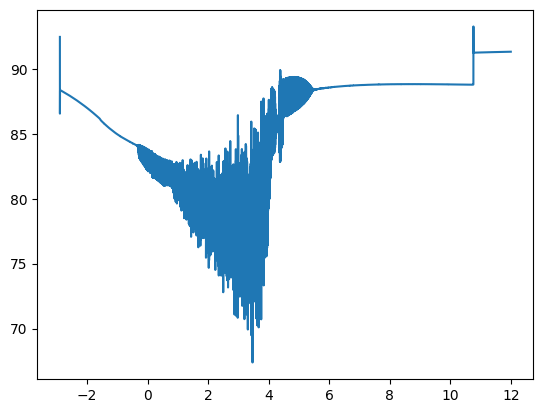

In [27]:
all_ain = np.repeat(Ain[None], len(A_intra) - 1, axis=0)
all_det = np.exp(-1j * np.repeat(detuning[...,None], len(tau), axis=1))
all_aout = np.sqrt(1 - coupling_coeff) * all_ain + 1j * np.sqrt(coupling_coeff) * all_det * np.array(A_intra[1:])
all_I = np.abs(all_aout) ** 2

# plt.plot( np.trapz(all_I, tau, axis=1) )
plt.plot(normalized_detuning, np.sum(all_I, axis=1) )

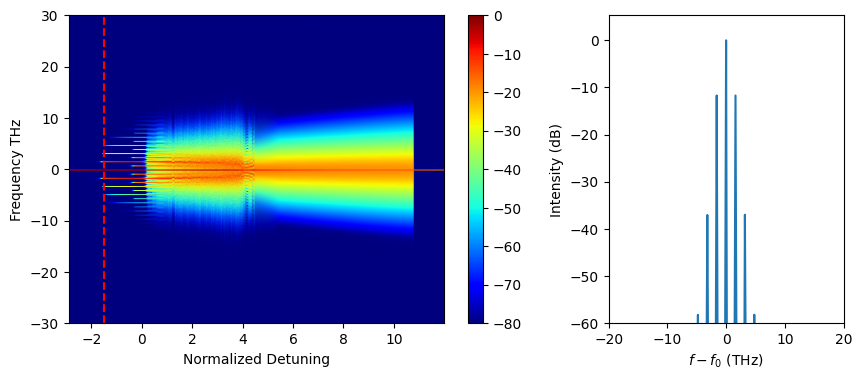

In [51]:
dB = lambda arr: 10 * np.log10( arr / np.max(arr) + np.finfo(arr.dtype).eps )

fig, axes = plt.subplots(ncols=2, figsize=(10,4), width_ratios=[2,1])

detuning_popout = -1.5
ind_popout = np.argmin(np.abs(normalized_detuning - detuning_popout))

# im = axes[0].imshow(10 * np.log10(data.T / np.max(data) + 1e-20), 
im = axes[0].imshow(dB(data).T, 
           extent=[np.min(normalized_detuning), np.max(normalized_detuning), np.min(freq), np.max(freq)], 
           vmin=-80, vmax=0, aspect='auto', cmap='jet')
axes[0].axvline(normalized_detuning[ind_popout], color='red', linestyle='--')
axes[0].set_xlabel('Normalized Detuning')
axes[0].set_ylabel('Frequency THz')
axes[0].set_ylim(-30, 30)
fig.colorbar(im)

cross_section = data[ind_popout]
axes[1].plot(freq, dB(cross_section))
axes[1].set_ylim(bottom=-60)
axes[1].set_xlim(-20, 20)
axes[1].set_xlabel('$f-f_0$ (THz)')
axes[1].set_ylabel('Intensity (dB)')
plt.show()